# **End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding**



# Import libraries

In [1]:
import os
import urllib.request
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import time
import pandas as pd
import ssl
import cv2

In [2]:
# Plot settings
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['savefig.dpi'] = 600

# Dataset and Experimental Setup

In [3]:
data_dir = "uci_har_data"
url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
zip_path = "uci_har.zip"

if not os.path.exists(data_dir):
    print("Downloading UCI HAR dataset...")
    urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)

    inner_zip = os.path.join(data_dir, "UCI HAR Dataset.zip")
    if os.path.exists(inner_zip):
        with zipfile.ZipFile(inner_zip, 'r') as zip_ref:
            zip_ref.extractall(data_dir)

dataset_base_path = os.path.join(data_dir, "UCI HAR Dataset")
print("Dataset successfully downloaded")

Dataset successfully downloaded


In [4]:
file_names_train = [
    "body_acc_x_train.txt", "body_acc_y_train.txt", "body_acc_z_train.txt",
    "body_gyro_x_train.txt", "body_gyro_y_train.txt", "body_gyro_z_train.txt",
    "total_acc_x_train.txt", "total_acc_y_train.txt", "total_acc_z_train.txt"
]

file_names_test = [
    "body_acc_x_test.txt", "body_acc_y_test.txt", "body_acc_z_test.txt",
    "body_gyro_x_test.txt", "body_gyro_y_test.txt", "body_gyro_z_test.txt",
    "total_acc_x_test.txt", "total_acc_y_test.txt", "total_acc_z_test.txt"
]

train_signals_dir = os.path.join(dataset_base_path, "train", "Inertial Signals")
test_signals_dir = os.path.join(dataset_base_path, "test", "Inertial Signals")

In [5]:
file_names_train = [
    "body_acc_x_train.txt", "body_acc_y_train.txt", "body_acc_z_train.txt",
    "body_gyro_x_train.txt", "body_gyro_y_train.txt", "body_gyro_z_train.txt",
    "total_acc_x_train.txt", "total_acc_y_train.txt", "total_acc_z_train.txt"
]

file_names_test = [
    "body_acc_x_test.txt", "body_acc_y_test.txt", "body_acc_z_test.txt",
    "body_gyro_x_test.txt", "body_gyro_y_test.txt", "body_gyro_z_test.txt",
    "total_acc_x_test.txt", "total_acc_y_test.txt", "total_acc_z_test.txt"
]

train_signals_dir = os.path.join(dataset_base_path, "train", "Inertial Signals")
test_signals_dir = os.path.join(dataset_base_path, "test", "Inertial Signals")

In [6]:
train_signals = []
for fname in file_names_train:
    train_signals.append(np.loadtxt(os.path.join(train_signals_dir, fname)))
X_train_raw = np.stack(train_signals, axis=-1)

test_signals = []
for fname in file_names_test:
    test_signals.append(np.loadtxt(os.path.join(test_signals_dir, fname)))
X_test_raw = np.stack(test_signals, axis=-1)

In [7]:
# Read labels
y_train_raw = np.loadtxt(os.path.join(dataset_base_path, "train", "y_train.txt"), dtype=int)
y_test_raw = np.loadtxt(os.path.join(dataset_base_path, "test", "y_test.txt"), dtype=int)

# Combine full pool and extract 3,000 subset window
X_full = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_full = np.concatenate([y_train_raw, y_test_raw], axis=0)

subset_size = 3000
X_subset = X_full[:subset_size]
y_subset = y_full[:subset_size]

In [8]:
# Convert 1-6 labels to 0-5 and one-hot encode
y_zero_indexed = y_subset - 1
y_encoded = tf.keras.utils.to_categorical(y_zero_indexed, num_classes=6)

# Stratified Split-  70% Train, 15% Val, 15% Test
X_train, X_temp, y_train, y_temp, y_labels_train, y_labels_temp = train_test_split(
    X_subset, y_encoded, y_zero_indexed,
    test_size=0.30, random_state=42, stratify=y_zero_indexed
)

X_val, X_test, y_val, y_test, y_labels_val, y_labels_test = train_test_split(
    X_temp, y_temp, y_labels_temp,
    test_size=0.50, random_state=42, stratify=y_labels_temp
)

# Normalize using train stats only
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)

X_train = (X_train - mean) / (std + 1e-8)
X_val = (X_val - mean) / (std + 1e-8)
X_test = (X_test - mean) / (std + 1e-8)

In [9]:
print("Input tensor shape:")
print(f"Training   : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Testing    : {X_test.shape}")
print(f"Number of classes: {y_encoded.shape[1]}")
print(f"Number of features per time step: {X_train.shape[2]}")
print(f"Sequence length: {X_train.shape[1]}")

print("\nClass Distribution Verification:")
for split_name, raw_labels in [("Train", y_labels_train), ("Validation3", y_labels_val), ("Test", y_labels_test)]:
    classes, counts = np.unique(raw_labels, return_counts=True)
    percentages = (counts / len(raw_labels)) * 100
    print(f"\n{split_name} Set Percentages:")
    for cls, pct in zip(classes, percentages):
        print(f"Class {cls+1}: {pct:.2f}%")

Input tensor shape:
Training   : (2100, 128, 9)
Validation : (450, 128, 9)
Testing    : (450, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class Distribution Verification:

Train Set Percentages:
Class 1: 18.95%
Class 2: 15.29%
Class 3: 13.71%
Class 4: 16.29%
Class 5: 17.67%
Class 6: 18.10%

Validation3 Set Percentages:
Class 1: 18.89%
Class 2: 15.33%
Class 3: 13.78%
Class 4: 16.22%
Class 5: 17.78%
Class 6: 18.00%

Test Set Percentages:
Class 1: 19.11%
Class 2: 15.11%
Class 3: 13.78%
Class 4: 16.44%
Class 5: 17.56%
Class 6: 18.00%


# Sensor signals

In [10]:
activity_names = {
    0: "Walking",
    1: "Walking Upstairs",
    2: "Sitting"
}

target_classes = [0, 1, 2]
selected_samples = {}

# Find the first sample corresponding to each target class
for cls in target_classes:
    idx = np.where(y_labels_train == cls)[0][0]
    selected_samples[cls] = X_train[idx]

In [11]:
# define Time Axis & Channels to Plot
time_steps = np.arange(1, 129)  # Time steps 1 to 128

# Channel indices: 0 = Body Accel X, 3 = Body Gyro X, 6 = Total Accel X
channel_indices = [0, 3, 6]
channel_labels = ["Body Accel X", "Body Gyro X", "Total Accel X"]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

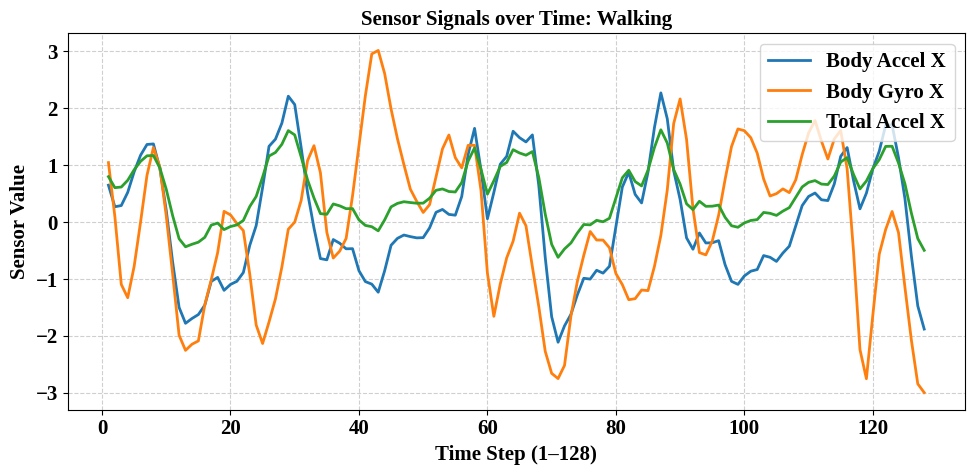

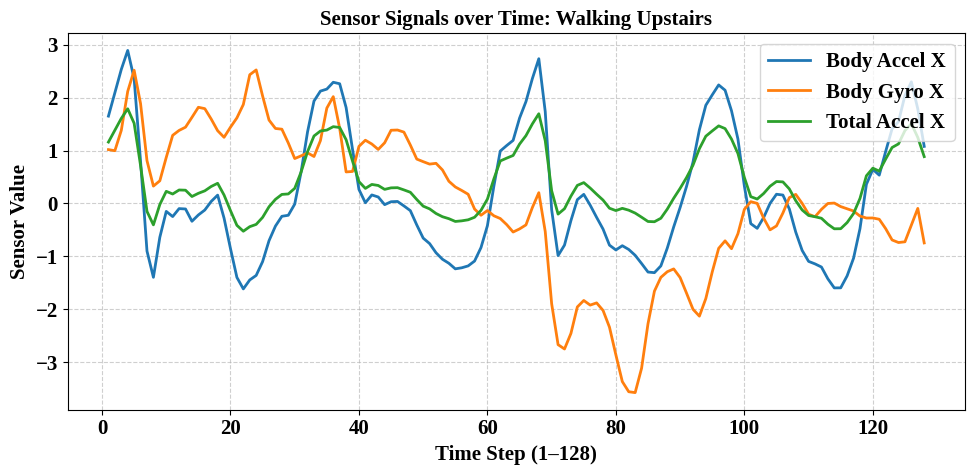

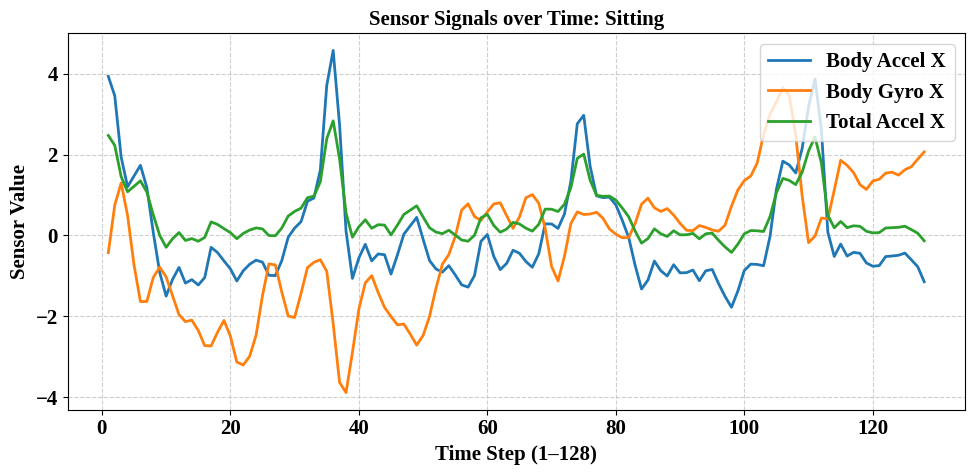

In [ ]:
# Plots for Each Activity Class
for cls in target_classes:
    sample_data = selected_samples[cls]

    plt.figure(figsize=(10, 5))

    # Plot chosen channels over time
    for ch_idx, label, color in zip(channel_indices, channel_labels, colors):
        plt.plot(time_steps, sample_data[:, ch_idx], label=label, color=color, linewidth=2)

    # Apply required labels, title, legend, and grid
    plt.title(f"Sensor Signals over Time: {activity_names[cls]}")
    plt.xlabel("Time Step (1–128)")
    plt.ylabel("Sensor Value")
    plt.legend(loc="upper right")
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.savefig(f"SensorSignals{activity_names[cls]}.png",dpi=600,bbox_inches="tight")
    plt.show()

# Vanilla RNN Architecture

In [ ]:
# Inputs
x = [0.5, 0.7, 0.2]
h_prev = 0.0

# Weights and bias
Wx = 0.5
Wh = 0.8
b = 0.1

# Compute hidden states
h_states = []
for t, xt in enumerate(x, start=1):
    z = Wx * xt + Wh * h_prev + b
    h_curr = np.tanh(z)
    h_states.append(h_curr)
    print(f"h_{t} = tanh({Wx}*{xt} + {Wh}*{h_prev:.6f} + {b}) = tanh({z:.6f}) = {h_curr:.6f}")
    h_prev = h_curr

print("\nComputed Hidden States [h1, h2, h3]:")
print([round(h, 6) for h in h_states])

h_1 = tanh(0.5*0.5 + 0.8*0.000000 + 0.1) = tanh(0.350000) = 0.336376
h_2 = tanh(0.5*0.7 + 0.8*0.336376 + 0.1) = tanh(0.719100) = 0.616352
h_3 = tanh(0.5*0.2 + 0.8*0.616352 + 0.1) = tanh(0.693081) = 0.599958

Computed Hidden States [h1, h2, h3]:
[np.float64(0.336376), np.float64(0.616352), np.float64(0.599958)]


# RNN

In [12]:
def build_sequence_model(model_type="RNN", units=32, dropout_rate=0.2, learning_rate=1e-3):

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(128, 9)))

    # Dynamically attach requested recurrent layer
    if model_type == "RNN":
        model.add(tf.keras.layers.SimpleRNN(units=units))
    elif model_type == "LSTM":
        model.add(tf.keras.layers.LSTM(units=units))
    elif model_type == "GRU":
        model.add(tf.keras.layers.GRU(units=units))
    else:
        raise ValueError("Invalid model_type. Choose 'RNN', 'LSTM', or 'GRU'.")

    model.add(tf.keras.layers.Dropout(rate=dropout_rate))
    model.add(tf.keras.layers.Dense(units=16, activation="relu"))
    model.add(tf.keras.layers.Dense(units=6, activation="softmax"))

    # Compile model using Sparse Categorical Cross-Entropy (accepts integer class labels)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [13]:
def build_sequence_model(model_type="RNN", units=32, dropout_rate=0.2, learning_rate=1e-3, input_shape=(None, 9)):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=input_shape))

    # Dynamically attach requested recurrent layer
    if model_type == "RNN":
        model.add(tf.keras.layers.SimpleRNN(units=units))
    elif model_type == "LSTM":
        model.add(tf.keras.layers.LSTM(units=units))
    elif model_type == "GRU":
        model.add(tf.keras.layers.GRU(units=units))
    else:
        raise ValueError("Invalid model_type. Choose 'RNN', 'LSTM', or 'GRU'.")

    model.add(tf.keras.layers.Dropout(rate=dropout_rate))
    model.add(tf.keras.layers.Dense(units=16, activation="relu"))
    model.add(tf.keras.layers.Dense(units=6, activation="softmax"))

    # Compile model using Sparse Categorical Cross-Entropy
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [14]:
def plot_train_vs_val(history, metric, val_metric, ylabel, title, filename, scale_to_pct=False):
    plt.figure(figsize=(10, 6))

    epochs = np.arange(1, len(history.history[metric]) + 1)
    train_vals = np.array(history.history[metric])
    val_vals = np.array(history.history[val_metric])

    if scale_to_pct:
        train_vals = train_vals * 100
        val_vals = val_vals * 100

    # Training Curve
    plt.plot(
        epochs,
        train_vals,
        label="Training",
        linewidth=2,
        marker="o",
        markersize=6,
        markevery=2,
        color="#1f77b4"
    )

    # Validation Curve
    plt.plot(
        epochs,
        val_vals,
        label="Validation",
        linewidth=2,
        marker="s",
        markersize=6,
        markevery=2,
        color="#ff7f0e",
        linestyle="--"
    )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend(loc="upper right" if "Loss" in ylabel else "lower right")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()

    plt.savefig(f"{filename}.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

In [15]:
def evaluate_test_metrics(model, X_test, y_test, model_name="Model"):
    # Fix target shape if y_test is One-Hot encoded
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test

    # 1. Predict class probabilities and convert to predicted labels
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 2. Calculate accuracy and macro-averaged metrics
    test_loss, test_acc = model.evaluate(X_test, y_true, verbose=0)
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # 3. Print results as percentages
    header = f"{model_name} test metrics report"
    print(f"{header}")
    print(f"Accuracy (%)        : {test_acc * 100:.2f}%")
    print(f"Macro Precision (%) : {precision_macro * 100:.2f}%")
    print(f"Macro Recall (%)    : {recall_macro * 100:.2f}%")
    print(f"Macro F1 (%)        : {f1_macro * 100:.2f}%")

    return {
        "Model": model_name,
        "Accuracy (%)": test_acc * 100,
        "Macro Precision (%)": precision_macro * 100,
        "Macro Recall (%)": recall_macro * 100,
        "Macro F1 (%)": f1_macro * 100
    }

In [16]:
def plot_confusion_matrix(model, X_test, y_test, class_names=None, model_name="Model"):
    # 1. Convert y_test to 1D integer labels if One-Hot encoded
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_true = np.argmax(y_test, axis=1)
    else:
        y_true = y_test

    # 2. Get model predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # 3. Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Fallback to numeric indices if no class names are provided
    if class_names is None:
        class_names = [f"Class {i}" for i in range(cm.shape[0])]

    # 4. Plot using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"size": 14, "weight": "bold"}
    )

    plt.title(f"{model_name}: Confusion Matrix", fontsize=12, fontweight="bold")
    plt.xlabel("Predicted Label", labelpad=10)
    plt.ylabel("True Label", labelpad=10)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()

    # 5. Save high-resolution plot for lab report
    filename = model_name.lower().replace(" ", "_").replace("–", "-")
    plt.savefig(f"{filename}_confusion_matrix.png", dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

# **RNN**

In [ ]:
# Build SimpleRNN
rnn_model = build_sequence_model(model_type="RNN", units=32, dropout_rate=0.2, learning_rate=1e-3)
rnn_model.summary()

# Train SimpleRNN
start_time = time.time()
history_rnn = rnn_model.fit(
    X_train, y_labels_train,
    validation_data=(X_val, y_labels_val),
    batch_size=32,
    epochs=30,
    verbose=1
)
elapsed_time = time.time() - start_time
print(f"Training time: {elapsed_time:.2f} seconds")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.3595 - loss: 1.5568 - val_accuracy: 0.5156 - val_loss: 1.3520
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5290 - loss: 1.1696 - val_accuracy: 0.6356 - val_loss: 1.0289
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6390 - loss: 0.9698 - val_accuracy: 0.6511 - val_loss: 0.9004
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6167 - loss: 1.0095 - val_accuracy: 0.6111 - val_loss: 1.0599
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6262 - loss: 0.9639 - val_accuracy: 0.6622 - val_loss: 0.8716
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6414 - loss: 0.8645 - val_accuracy: 0.6911 - val_loss: 0.7615
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6514 - loss: 0.8122 - val_accuracy: 0.7022 - val_loss: 0.7712
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6900 - loss: 0.7353 - val_accuracy: 0.7044 - v

##  Training and Validation Loss Plot

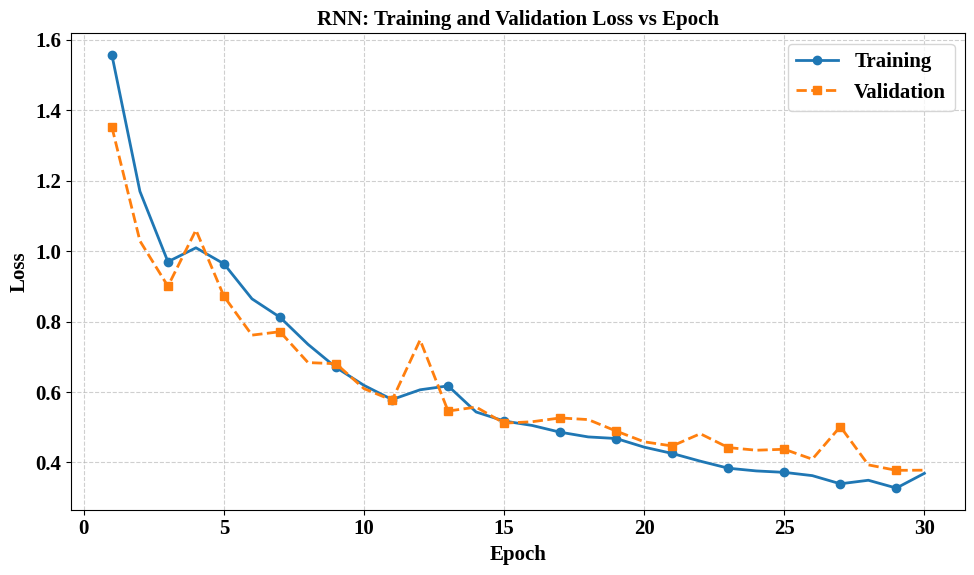

In [ ]:
# Plot 1: Loss (Training vs Validation)
plot_train_vs_val(
    history=history_rnn,
    metric="loss",
    val_metric="val_loss",
    ylabel="Loss",
    title="RNN: Training and Validation Loss vs Epoch",
    filename="rnn_loss",
    scale_to_pct=False
)

##  Training and Validation Accuracy Plot


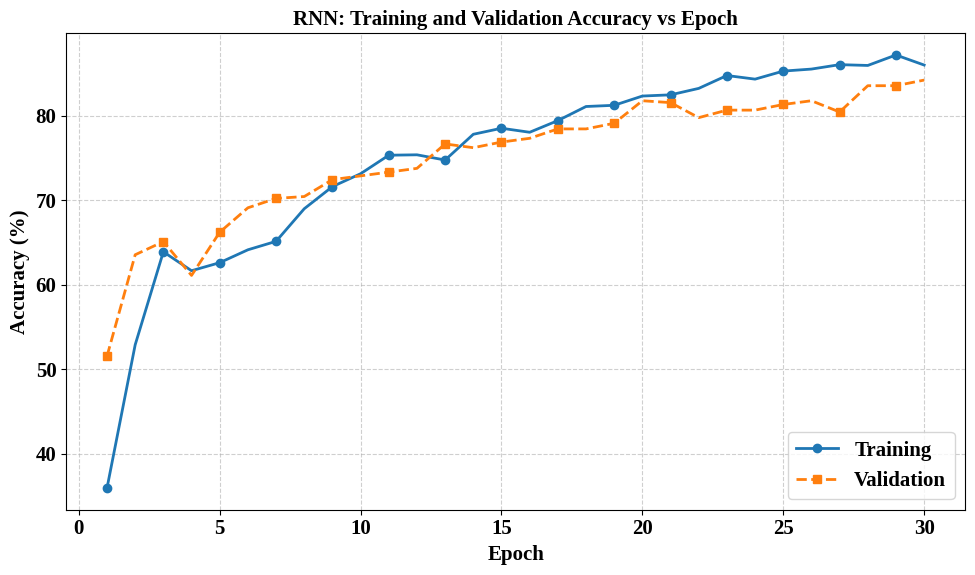

In [ ]:
# Plot 2: Accuracy (Training vs Validation)
plot_train_vs_val(
    history=history_rnn,
    metric="accuracy",
    val_metric="val_accuracy",
    ylabel="Accuracy (%)",
    title="RNN: Training and Validation Accuracy vs Epoch",
    filename="rnn_accuracy",
    scale_to_pct=True
)

In [ ]:
rnn_metrics = evaluate_test_metrics(rnn_model, X_test, y_test, model_name="RNN")

RNN test metrics report
Accuracy (%)        : 84.67%
Macro Precision (%) : 84.52%
Macro Recall (%)    : 84.27%
Macro F1 (%)        : 83.99%


In [ ]:
har_activities = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

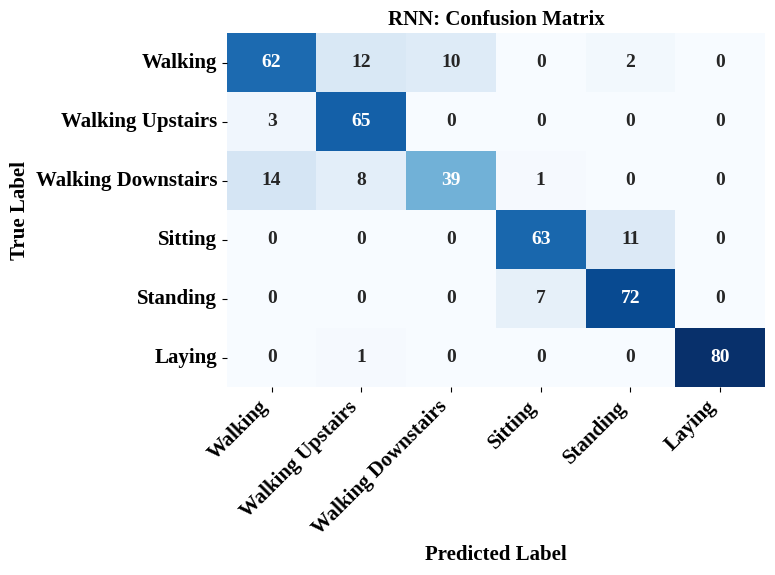

In [ ]:
plot_confusion_matrix(rnn_model, X_test, y_test,class_names=har_activities, model_name="RNN")

# **LSTM**

In [ ]:
lstm_model = build_sequence_model(
    model_type="LSTM",
    units=32,
    dropout_rate=0.2,
    learning_rate=1e-3
)
lstm_model.summary()

# Train LSTM
start_time = time.time()
history_lstm = lstm_model.fit(
    X_train, y_labels_train,
    validation_data=(X_val, y_labels_val),
    batch_size=32,
    epochs=30,
    verbose=1
)
time_lstm = time.time() - start_time
print(f"Training time: {time_lstm:.2f} seconds")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,006 (23.46 KB)

 Trainable params: 6,006 (23.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.3743 - loss: 1.5824 - val_accuracy: 0.5289 - val_loss: 1.3477
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5624 - loss: 1.1471 - val_accuracy: 0.6111 - val_loss: 0.9192
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.7486 - loss: 0.7509 - val_accuracy: 0.8222 - val_loss: 0.5836
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8519 - loss: 0.5138 - val_accuracy: 0.8800 - val_loss: 0.4003
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8910 - loss: 0.3890 - val_accuracy: 0.9222 - val_loss: 0.2881
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.9238 - loss: 0.2657 - val_accuracy: 0.9467 - val_loss: 0.2024
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9262 - loss: 0.2506 - val_accuracy: 0.9289 - val_loss: 0.2001
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9548 - loss: 0.1770 - val_accuracy: 0.9489 - v

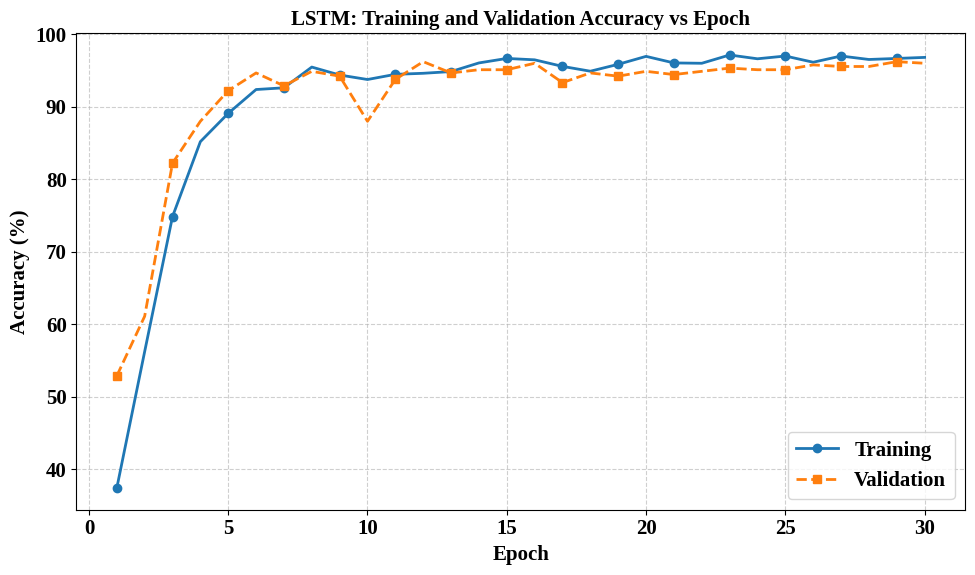

In [ ]:
# Plot 2: Accuracy (Training vs Validation)
plot_train_vs_val(
    history=history_lstm,
    metric="accuracy",
    val_metric="val_accuracy",
    ylabel="Accuracy (%)",
    title="LSTM: Training and Validation Accuracy vs Epoch",
    filename="lstm_accuracy",
    scale_to_pct=True
)

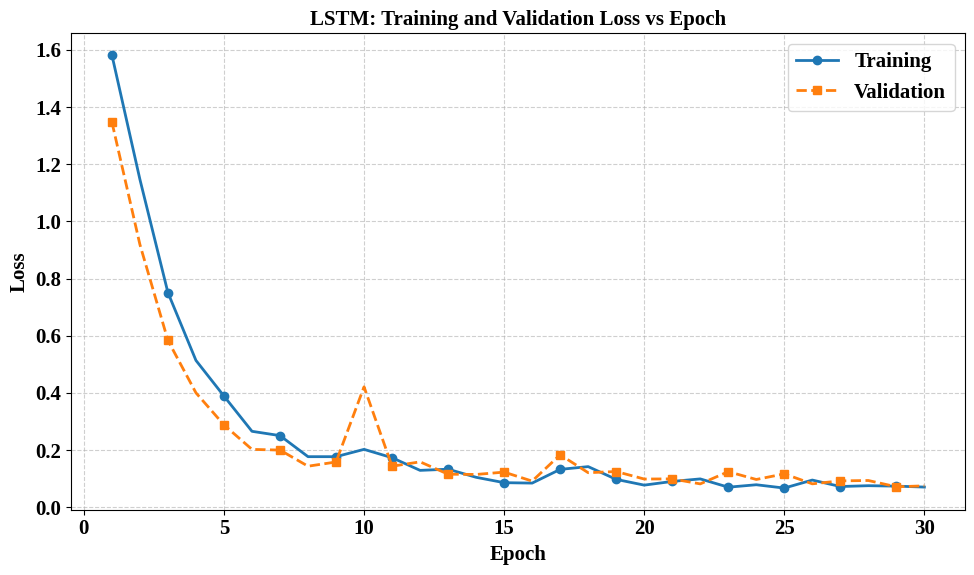

In [ ]:
# Plot 1: Loss (Training vs Validation)
plot_train_vs_val(
    history=history_lstm,
    metric="loss",
    val_metric="val_loss",
    ylabel="Loss",
    title="LSTM: Training and Validation Loss vs Epoch",
    filename="lstm_loss",
    scale_to_pct=False
)

In [ ]:
lstm_metrics = evaluate_test_metrics(lstm_model, X_test, y_test, model_name="LSTM")

LSTM test metrics report
Accuracy (%)        : 95.78%
Macro Precision (%) : 95.83%
Macro Recall (%)    : 95.86%
Macro F1 (%)        : 95.82%


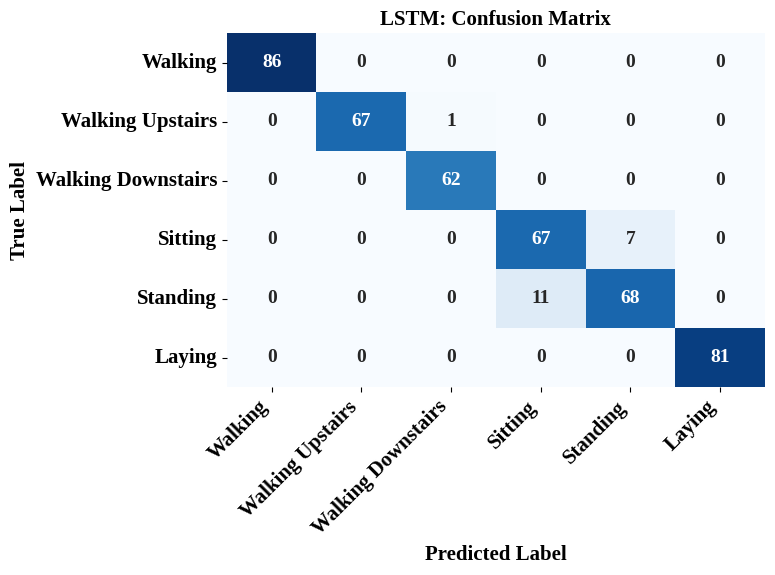

In [ ]:
plot_confusion_matrix(lstm_model, X_test, y_test,class_names=har_activities,model_name="LSTM")

# **GRU**

In [ ]:
gru_model = build_sequence_model(
    model_type="GRU",
    units=32,
    dropout_rate=0.2,
    learning_rate=1e-3
)
gru_model.summary()

# Train GRU
start_time = time.time()
history_gru = gru_model.fit(
    X_train, y_labels_train,
    validation_data=(X_val, y_labels_val),
    batch_size=32,
    epochs=30,
    verbose=1
)
time_gru = time.time() - start_time
print(f"Training time: {time_gru:.2f} seconds")

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,758 (18.59 KB)

 Trainable params: 4,758 (18.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.3471 - loss: 1.5683 - val_accuracy: 0.5311 - val_loss: 1.3657
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.5781 - loss: 1.2536 - val_accuracy: 0.6067 - val_loss: 1.0640
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 134ms/step - accuracy: 0.6562 - loss: 0.9185 - val_accuracy: 0.7067 - val_loss: 0.7231
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.7148 - loss: 0.6755 - val_accuracy: 0.7511 - val_loss: 0.5951
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 118ms/step - accuracy: 0.7676 - loss: 0.5504 - val_accuracy: 0.8200 - val_loss: 0.4957
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.8224 - loss: 0.4851 - val_accuracy: 0.8533 - val_loss: 0.4461
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step - accuracy: 0.8690 - loss: 0.3936 - val_accuracy: 0.8822 - val_loss: 0.3264
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.9057 - loss: 0.2827 - val_accuracy: 0.9

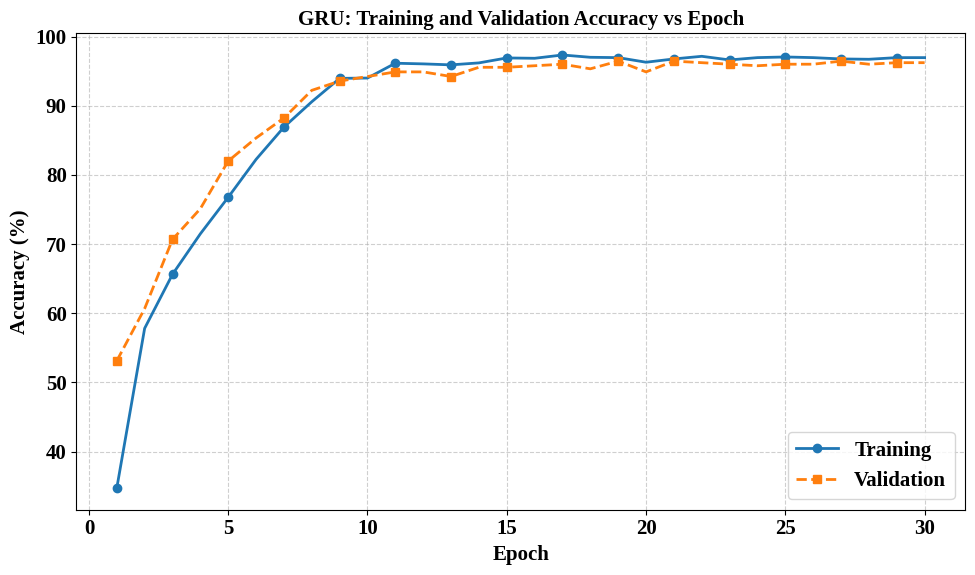

In [ ]:
# Plot 2: Accuracy (Training vs Validation)
plot_train_vs_val(
    history=history_gru,
    metric="accuracy",
    val_metric="val_accuracy",
    ylabel="Accuracy (%)",
    title="GRU: Training and Validation Accuracy vs Epoch",
    filename="gru_accuracy",
    scale_to_pct=True
)

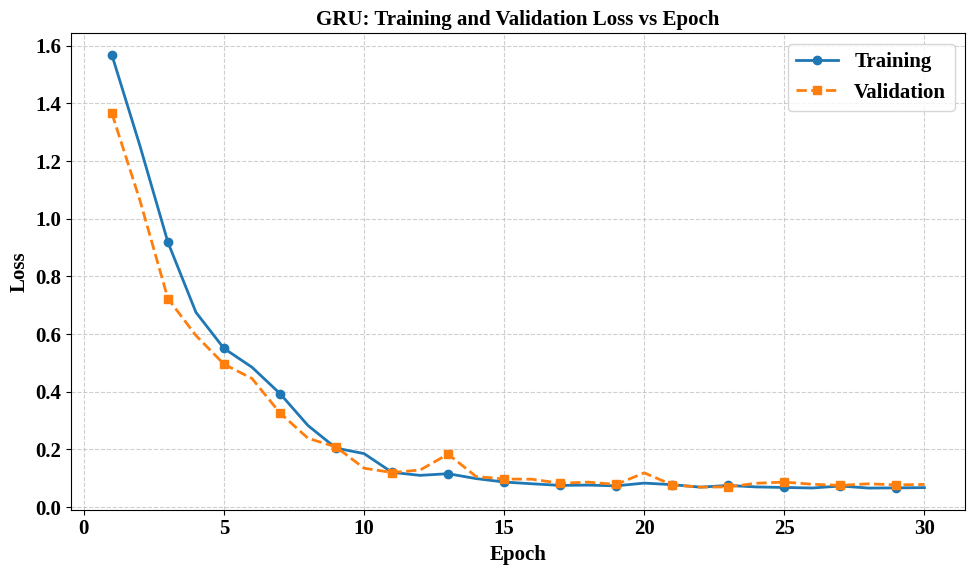

In [ ]:
# Plot 1: Loss (Training vs Validation)
plot_train_vs_val(
    history=history_gru,
    metric="loss",
    val_metric="val_loss",
    ylabel="Loss",
    title="GRU: Training and Validation Loss vs Epoch",
    filename="gru_loss",
    scale_to_pct=False
)

In [ ]:
gru_metrics = evaluate_test_metrics(gru_model, X_test, y_test, model_name="GRU")

GRU test metrics report
Accuracy (%)        : 96.22%
Macro Precision (%) : 96.37%
Macro Recall (%)    : 96.34%
Macro F1 (%)        : 96.30%


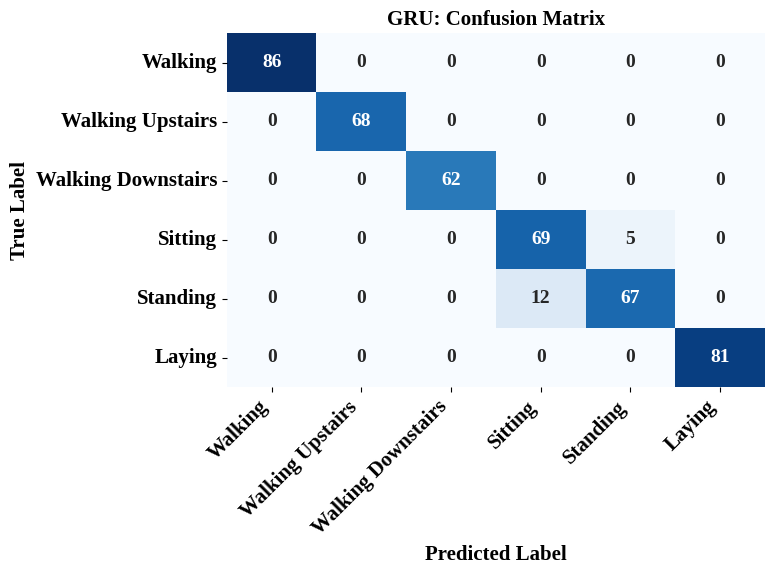

In [ ]:
plot_confusion_matrix(gru_model, X_test, y_test, class_names=har_activities,model_name="GRU")

RNN test metrics report
Accuracy (%)        : 84.67%
Macro Precision (%) : 84.52%
Macro Recall (%)    : 84.27%
Macro F1 (%)        : 83.99%
LSTM test metrics report
Accuracy (%)        : 95.78%
Macro Precision (%) : 95.83%
Macro Recall (%)    : 95.86%
Macro F1 (%)        : 95.82%
GRU test metrics report
Accuracy (%)        : 96.22%
Macro Precision (%) : 96.37%
Macro Recall (%)    : 96.34%
Macro F1 (%)        : 96.30%


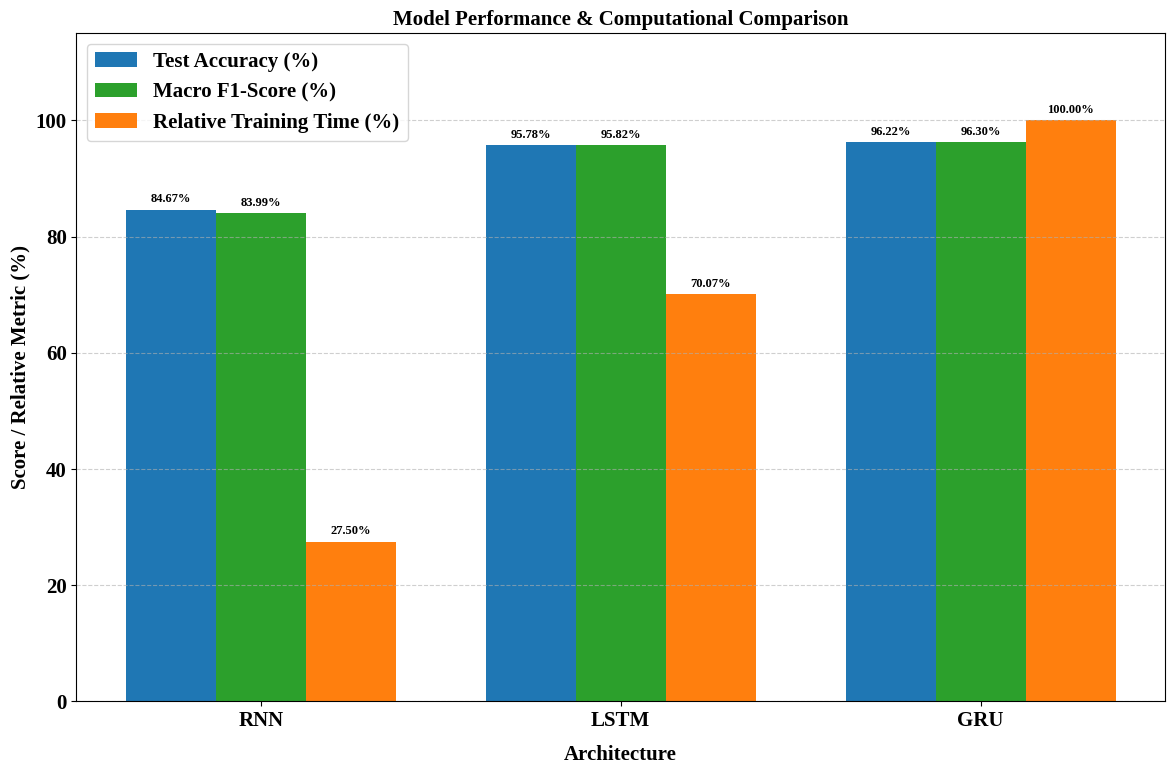

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# List of models and their stored training times
models_info = [
    ("RNN", rnn_model, elapsed_time),
    ("LSTM", lstm_model, time_lstm),
    ("GRU", gru_model, time_gru)
]

names = []
accuracies = []
f1_scores = []
raw_times = []

# Collect metrics from each model
for name, model, t_time in models_info:
    metrics = evaluate_test_metrics(model, X_test, y_test, model_name=name)
    names.append(name)
    accuracies.append(metrics["Accuracy (%)"])
    f1_scores.append(metrics["Macro F1 (%)"])
    raw_times.append(t_time)

# Normalize training time relative to the maximum time taken (scaled to 0-100%)
max_time = max(raw_times) if max(raw_times) > 0 else 1.0
normalized_times = [(t / max_time) * 100 for t in raw_times]

# Set up bar positions
x = np.arange(len(names))
width = 0.25

plt.figure(figsize=(12, 8))

# Plot bars and store containers for labeling
rects1 = plt.bar(x - width, accuracies, width, label='Test Accuracy (%)', color='#1f77b4')
rects2 = plt.bar(x, f1_scores, width, label='Macro F1-Score (%)', color='#2ca02c')
rects3 = plt.bar(x + width, normalized_times, width, label='Relative Training Time (%)', color='#ff7f0e')

# Function to add numerical labels on top of bars
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(
            f'{height:.2f}%',
            xy=(rect.get_x() + rect.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

# Annotate each group of bars
add_labels(rects1)
add_labels(rects2)
add_labels(rects3)

# Graph details
plt.xlabel("Architecture", labelpad=10)
plt.ylabel("Score / Relative Metric (%)")
plt.title("Model Performance & Computational Comparison")
plt.xticks(x, names)
plt.ylim(0, 115)  # Leave room above bars for labels
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6, axis='y')
plt.tight_layout()

# Save high-res figure for report
plt.savefig("model_performance_comparison.png", dpi=600, bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
sequence_lengths = [32, 64, 128]
results_list = []

print("Sequence Length Experiment\n")

for T in sequence_lengths:
    print(f"Sequence Length T = {T}\n")

    # 1. Truncate inputs consistently to shape (N, T, 9)
    X_tr_sub = X_train[:, :T, :]
    X_val_sub = X_val[:, :T, :]
    X_te_sub  = X_test[:, :T, :]

    row = {"Sequence Length": T}

    for arch in ["RNN", "LSTM", "GRU"]:
        print(f"\nTraining {arch} (T={T})\n")

        # 2. Re-instantiate a fresh model
        model = build_sequence_model(model_type=arch, units=32, dropout_rate=0.2, learning_rate=1e-3)

        # 3. Fit on truncated sequences
        model.fit(
            X_tr_sub, y_labels_train,
            validation_data=(X_val_sub, y_labels_val),
            batch_size=32,
            epochs=30,
            verbose=0
        )

        # 4. Evaluate Macro F1-score on test set using updated evaluate_test_metrics function
        metrics = evaluate_test_metrics(model, X_te_sub, y_test, model_name=f"{arch} (T={T})")

        # Store Macro F1 value
        if arch == "RNN":
            row["RNN F1"] = f"{metrics['Macro F1 (%)']:.2f}%"
        elif arch == "LSTM":
            row["LSTM F1"] = f"{metrics['Macro F1 (%)']:.2f}%"
        elif arch == "GRU":
            row["GRU F1"] = f"{metrics['Macro F1 (%)']:.2f}%"

    results_list.append(row)

# 5. Display requested table format
df_seq_len = pd.DataFrame(results_list)

print("Effect of sequence length on macro F1-score")
print(df_seq_len.to_string(index=False))

Sequence Length Experiment

Sequence Length T = 32


Training RNN (T=32)

RNN (T=32) test metrics report
Accuracy (%)        : 78.67%
Macro Precision (%) : 79.61%
Macro Recall (%)    : 78.01%
Macro F1 (%)        : 78.20%

Training LSTM (T=32)

LSTM (T=32) test metrics report
Accuracy (%)        : 94.22%
Macro Precision (%) : 94.36%
Macro Recall (%)    : 94.22%
Macro F1 (%)        : 94.20%

Training GRU (T=32)

GRU (T=32) test metrics report
Accuracy (%)        : 94.89%
Macro Precision (%) : 95.29%
Macro Recall (%)    : 95.01%
Macro F1 (%)        : 94.95%
Sequence Length T = 64


Training RNN (T=64)

RNN (T=64) test metrics report
Accuracy (%)        : 74.89%
Macro Precision (%) : 78.03%
Macro Recall (%)    : 72.81%
Macro F1 (%)        : 72.01%

Training LSTM (T=64)

LSTM (T=64) test metrics report
Accuracy (%)        : 96.67%
Macro Precision (%) : 96.82%
Macro Recall (%)    : 96.63%
Macro F1 (%)        : 96.71%

Training GRU (T=64)

GRU (T=64) test metrics report
Accuracy (%)        : 

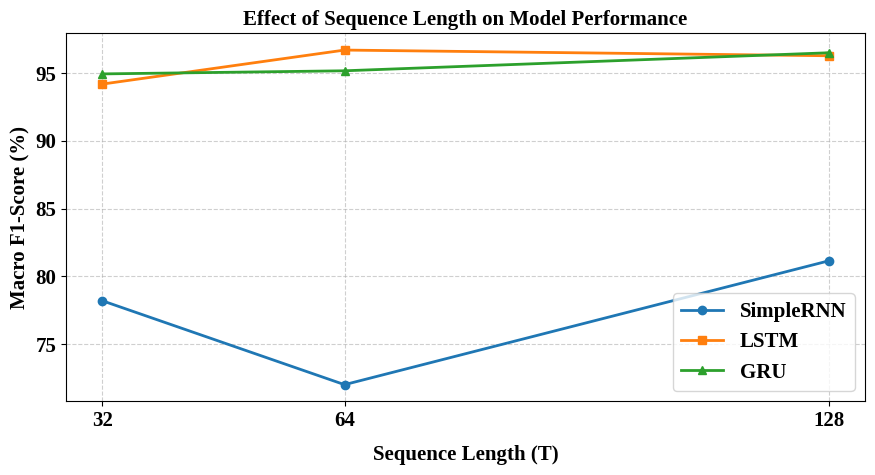

In [ ]:
# Extract float values for plotting
f1_rnn = [float(row["RNN F1"].replace("%", "")) for row in results_list]
f1_lstm = [float(row["LSTM F1"].replace("%", "")) for row in results_list]
f1_gru = [float(row["GRU F1"].replace("%", "")) for row in results_list]

plt.figure(figsize=(9, 5))

plt.plot(sequence_lengths, f1_rnn, marker='o', linewidth=2, label='SimpleRNN', color='#1f77b4')
plt.plot(sequence_lengths, f1_lstm, marker='s', linewidth=2, label='LSTM', color='#ff7f0e')
plt.plot(sequence_lengths, f1_gru, marker='^', linewidth=2, label='GRU', color='#2ca02c')

plt.xlabel("Sequence Length (T)", labelpad=10)
plt.ylabel("Macro F1-Score (%)")
plt.title("Effect of Sequence Length on Model Performance")
plt.xticks(sequence_lengths)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig("effect_of_sequence_length.png", dpi=600, bbox_inches="tight")
plt.show()
plt.close()

# **Video Understanding Using CNN and RNN**

In [ ]:
# Define selected classes and target directory
SELECTED_CLASSES = ["Basketball", "Biking", "TennisSwing"]
DATASET_DIR = "ucf101_mini"
os.makedirs(DATASET_DIR, exist_ok=True)

# UCF101 official mirror source
BASE_URL = "https://www.crcv.ucf.edu/THUMOS14/UCF101/UCF101/"

# --- FIX: Bypass SSL certificate verification ---
ssl_context = ssl._create_unverified_context()

print("Downloading UCF101 subset videos...")
for cls in SELECTED_CLASSES:
    cls_dir = os.path.join(DATASET_DIR, cls)
    os.makedirs(cls_dir, exist_ok=True)

    # Download first 10 sample videos per class
    for i in range(1, 11):
        video_name = f"v_{cls}_g01_c0{i}.avi" if i < 10 else f"v_{cls}_g01_c10.avi"
        video_url = f"{BASE_URL}{video_name}"
        save_path = os.path.join(cls_dir, video_name)

        if not os.path.exists(save_path):
            try:
                # Pass unverified ssl context to urlopen
                with urllib.request.urlopen(video_url, context=ssl_context) as response, open(save_path, 'wb') as out_file:
                    out_file.write(response.read())
                print(f"Downloaded: {video_name}")
            except Exception as e:
                print(f"Skipped {video_name}: {e}")

print("\nDataset preparation complete!")

Downloaded: v_Basketball_g01_c01.avi
Downloaded: v_Basketball_g01_c02.avi
Downloaded: v_Basketball_g01_c03.avi
Downloaded: v_Basketball_g01_c04.avi
Downloaded: v_Basketball_g01_c05.avi
Downloaded: v_Basketball_g01_c06.avi
Downloaded: v_Basketball_g01_c07.avi
Downloaded: v_Basketball_g01_c08.avi
Downloaded: v_Basketball_g01_c09.avi
Downloaded: v_Basketball_g01_c10.avi
Downloaded: v_Biking_g01_c01.avi
Downloaded: v_Biking_g01_c02.avi
Downloaded: v_Biking_g01_c03.avi
Downloaded: v_Biking_g01_c04.avi
Downloaded: v_Biking_g01_c05.avi
Downloaded: v_Biking_g01_c06.avi
Downloaded: v_Biking_g01_c07.avi
Downloaded: v_Biking_g01_c08.avi
Downloaded: v_Biking_g01_c09.avi
Downloaded: v_Biking_g01_c10.avi
Downloaded: v_TennisSwing_g01_c01.avi
Downloaded: v_TennisSwing_g01_c02.avi
Downloaded: v_TennisSwing_g01_c03.avi
Downloaded: v_TennisSwing_g01_c04.avi
Downloaded: v_TennisSwing_g01_c05.avi
Downloaded: v_TennisSwing_g01_c06.avi
Downloaded: v_TennisSwing_g01_c07.avi
Downloaded: v_TennisSwing_g01_c08.

In [ ]:

# 1. Load Pretrained MobileNetV2 as a frozen feature extractor (Output shape: D = 1280)
feature_extractor = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
feature_extractor.trainable = False

def extract_video_features(video_path, num_frames=10, target_size=(224, 224)):
    """
    Samples `num_frames` uniformly from a video, preprocesses them,
    and extracts a feature matrix X of shape (num_frames, D).
    """
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if total_frames <= 0:
        cap.release()
        return None

    # Compute uniform frame indices
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames = []

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, target_size)
        frames.append(frame)

    cap.release()

    # If video reading failed or fell short on frames, pad/truncate to exactly `num_frames`
    if len(frames) == 0:
        return None
    while len(frames) < num_frames:
        frames.append(frames[-1])

    frames = np.array(frames[:num_frames], dtype=np.float32)

    # Apply MobileNetV2 specific preprocessing [-1, 1]
    preprocessed_frames = preprocess_input(frames)

    # Extract feature matrix X in R^(10 x D)
    feature_matrix = feature_extractor.predict(preprocessed_frames, verbose=0)
    return feature_matrix

# Process all downloaded dataset videos
X_features = []
y_labels = []

label_map = {cls_name: idx for idx, cls_name in enumerate(SELECTED_CLASSES)}

print("Extracting CNN features across sampled videos...")
for cls_name, label_idx in label_map.items():
    cls_folder = os.path.join(DATASET_DIR, cls_name)
    for vid_file in os.listdir(cls_folder):
        if vid_file.endswith(".avi"):
            vid_path = os.path.join(cls_folder, vid_file)
            feats = extract_video_features(vid_path, num_frames=10)
            if feats is not None:
                X_features.append(feats)
                y_labels.append(label_idx)

X = np.array(X_features)  # Shape: (B, 10, 1280)
y = np.array(y_labels)    # Shape: (B,)

print(f"\nFinal Preprocessed Feature Tensor Shape : {X.shape}")
print(f"Final Class Labels Tensor Shape          : {y.shape}")

/tmp/ipykernel_526/3429659271.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  feature_extractor = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Extracting CNN features across sampled videos...

Final Preprocessed Feature Tensor Shape : (18, 10, 1280)
Final Class Labels Tensor Shape          : (18,)


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Build Sequence Classifier (Input shape: (T=10, D=1280))
video_recurrent_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10, X.shape[2])),
    tf.keras.layers.GRU(units=32, dropout=0.2),
    tf.keras.layers.Dense(units=16, activation="relu"),
    tf.keras.layers.Dense(units=len(SELECTED_CLASSES), activation="softmax")
])

video_recurrent_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
video_recurrent_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 32)             │       126,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,723 (495.01 KB)

 Trainable params: 126,723 (495.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = time.time()
# Train Recurrent Classifier
history_video = video_recurrent_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=4,
    verbose=1
)
video_training_time = time.time() - start_time
print(f"Training time: {video_training_time:.2f} seconds")

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 209ms/step - accuracy: 0.5000 - loss: 1.1774 - val_accuracy: 0.6667 - val_loss: 0.8206
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8333 - loss: 0.5104 - val_accuracy: 0.6667 - val_loss: 0.5310
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9167 - loss: 0.2792 - val_accuracy: 0.8333 - val_loss: 0.3172
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 1.0000 - loss: 0.1703 - val_accuracy: 1.0000 - val_loss: 0.2196
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.1183 - val_accuracy: 1.0000 - val_loss: 0.1608
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.0833 - val_accuracy: 1.0000 - val_loss: 0.1276
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 0.0678 - val_accuracy: 1.0000 - val_loss: 0.1040
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 1.0000 - loss: 0.0597 - val_accuracy: 1.0000 - val_loss: 0.0910

In [ ]:
def predict_video_action(model, X_sample, y_sample_true, class_names):
    # Reshape single video to batch shape: (1, 10, 1280)
    X_sample_batch = np.expand_dims(X_sample, axis=0)

    # obtain output probability vector from the trained model
    probabilities = model.predict(X_sample_batch, verbose=0)[0]

    # Derive predicted class index and confidence value
    pred_idx = np.argmax(probabilities)
    confidence = probabilities[pred_idx]

    pred_class = class_names[pred_idx]
    actual_class = class_names[y_sample_true]

    print("Video action recognition result:")
    print(f"Predicted class : {pred_class}")
    print(f"Actual class    : {actual_class}")
    print(f"Confidence      : {confidence:.2f}")

    return pred_class, confidence

In [ ]:
sample_idx = 0
predict_video_action(
    model=video_recurrent_model,
    X_sample=X_test[sample_idx],
    y_sample_true=y_test[sample_idx],
    class_names=SELECTED_CLASSES
)

Video action recognition result:
Predicted class : Biking
Actual class    : Biking
Confidence      : 0.94


('Biking', np.float32(0.94152445))

In [ ]:
# 1. Extract dimensions directly from the generated feature tensor
batch_size, sequence_length, feature_dim = X.shape

print("CNN Feature extraction and tensor shapre report")

print(f"Pretrained CNN Backbone      : MobileNetV2 (Frozen)")
print(f"CNN Feature Dimension (D)    : {feature_dim}")
print(f"Uniform Sequence Length (T)  : {sequence_length} frames")
print(f"Total Video Samples (B)      : {batch_size}")
print()
print(f"Single Video Feature Matrix  : X_i ∈ ℝ^({sequence_length} × {feature_dim})")
print(f"Full Dataset Input Tensor    : X   ∈ ℝ^({batch_size} × {sequence_length} × {feature_dim})")
print(f"Recurrent Input Shape        : (batch_size, {sequence_length}, {feature_dim})")

CNN Feature extraction and tensor shapre report
Pretrained CNN Backbone      : MobileNetV2 (Frozen)
CNN Feature Dimension (D)    : 1280
Uniform Sequence Length (T)  : 10 frames
Total Video Samples (B)      : 18

Single Video Feature Matrix  : X_i ∈ ℝ^(10 × 1280)
Full Dataset Input Tensor    : X   ∈ ℝ^(18 × 10 × 1280)
Recurrent Input Shape        : (batch_size, 10, 1280)


In [ ]:

def plot_video_sample_frames_fixed(video_path, num_frames=10, save_filename="video_sample_frames.png"):
    if not os.path.exists(video_path):
        raise FileNotFoundError(f"Video file not found at path: {video_path}")

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"OpenCV could not open video file: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Handle cases where frame count read fails
    if total_frames <= 0:
        cap.release()
        raise ValueError(f"Video file contains 0 frames or invalid codec header: {video_path}")

    # Generate 10 uniform frame indices
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)

    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret and frame is not None:
            # 1. Convert BGR (OpenCV) to RGB (Matplotlib)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # 2. Resize to required target shape
            frame_resized = cv2.resize(frame_rgb, (224, 224))

            # 3. Ensure explicit uint8 data type [0, 255]
            frame_resized = frame_resized.astype(np.uint8)

            frames.append(frame_resized)

    cap.release()

    # Safety check
    if len(frames) == 0:
        raise RuntimeError("Failed to extract any valid frames from the video.")

    # Define layout: 3 rows x 4 columns (Total 12 grid cells, 10 used for frames)
    rows, cols = 3, 4
    plt.figure(figsize=(10, 8))  # Set figure size directly here

    for i in range(len(frames)):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(frames[i])
        plt.title(f"Frame {i+1}", fontsize=10)
        plt.axis("off")

    # Hide unused extra subplots (cell 11 and 12)
    for i in range(len(frames) + 1, rows * cols + 1):
        ax = plt.subplot(rows, cols, i)
        ax.axis("off")

    plt.suptitle("Uniformly Sampled Video Frames (T=10)", y=0.98, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(save_filename, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close()

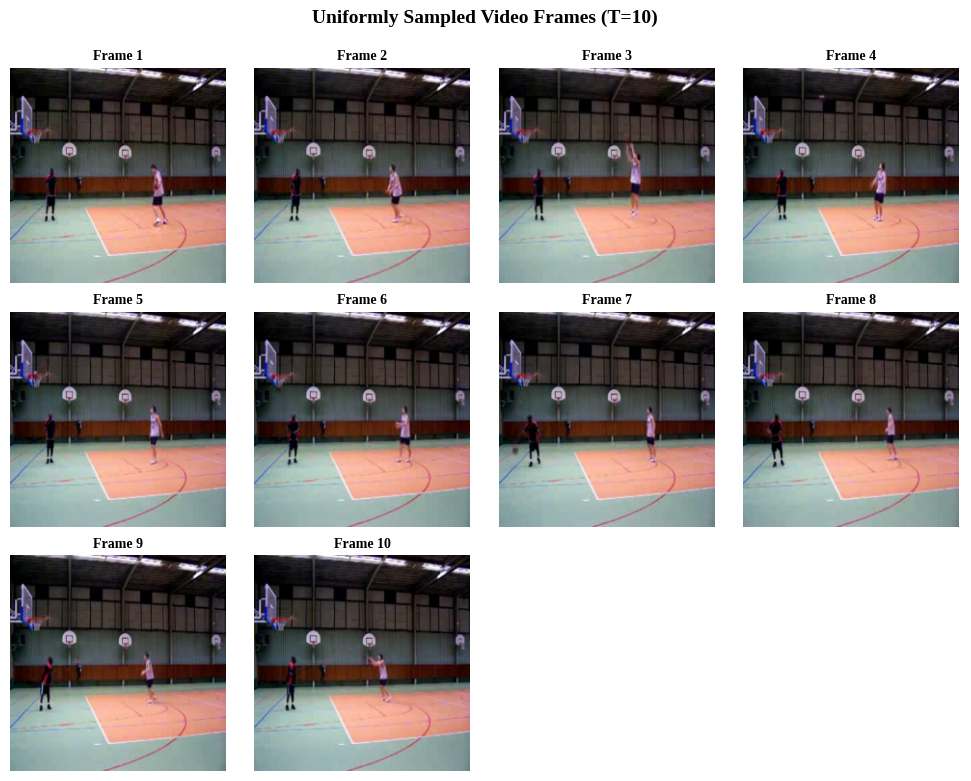

In [ ]:
sample_class = SELECTED_CLASSES[0]
sample_dir = os.path.join(DATASET_DIR, sample_class)

# Get all .avi files in the directory
video_files = [f for f in os.listdir(sample_dir) if f.endswith(".avi")]

if not video_files:
    raise FileNotFoundError(f"No video files found in {sample_dir}")

# Try to find a playable video
sample_video = None
for video_file_name in video_files:
    current_video_path = os.path.join(sample_dir, video_file_name)
    cap = cv2.VideoCapture(current_video_path)
    if cap.isOpened():
        sample_video = current_video_path
        cap.release()
        break
    cap.release() # Release if not opened to prevent resource leak

if sample_video is None:
    raise ValueError(f"Could not open any valid video file in {sample_dir}")

plot_video_sample_frames_fixed(sample_video)

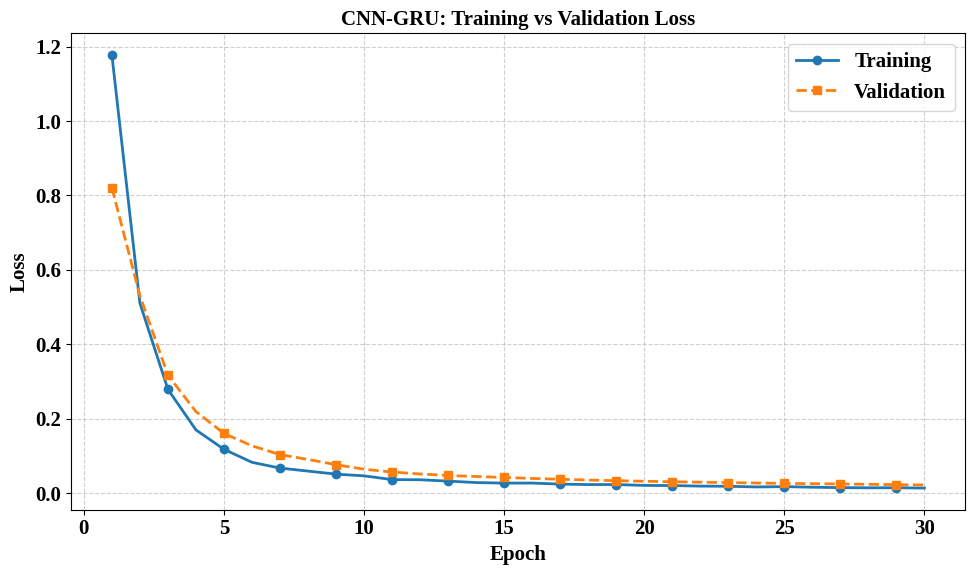

In [ ]:
plot_train_vs_val(
    history=history_video,
    metric="loss",
    val_metric="val_loss",
    ylabel="Loss",
    title="CNN-GRU: Training vs Validation Loss",
    filename="video_loss",
    scale_to_pct=False
)

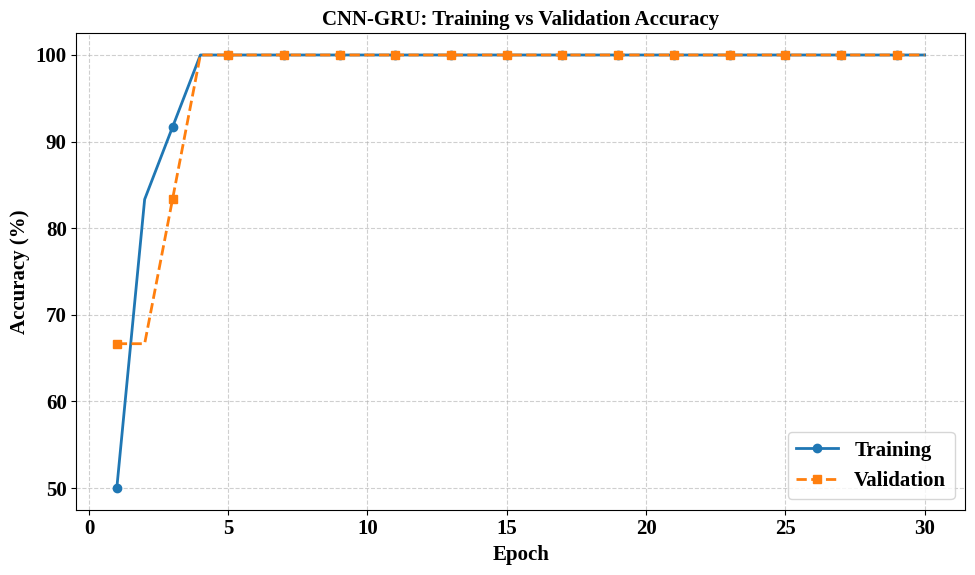

In [ ]:
# Function Call 2: Video Model Accuracy Curve
plot_train_vs_val(
    history=history_video,
    metric="accuracy",
    val_metric="val_accuracy",
    ylabel="Accuracy (%)",
    title="CNN-GRU: Training vs Validation Accuracy",
    filename="video_accuracy",
    scale_to_pct=True
)

In [ ]:
video_gru_metrics = evaluate_test_metrics(video_recurrent_model, X_test, y_test, model_name="CNN-GRU")

CNN-GRU test metrics report
Accuracy (%)        : 100.00%
Macro Precision (%) : 100.00%
Macro Recall (%)    : 100.00%
Macro F1 (%)        : 100.00%


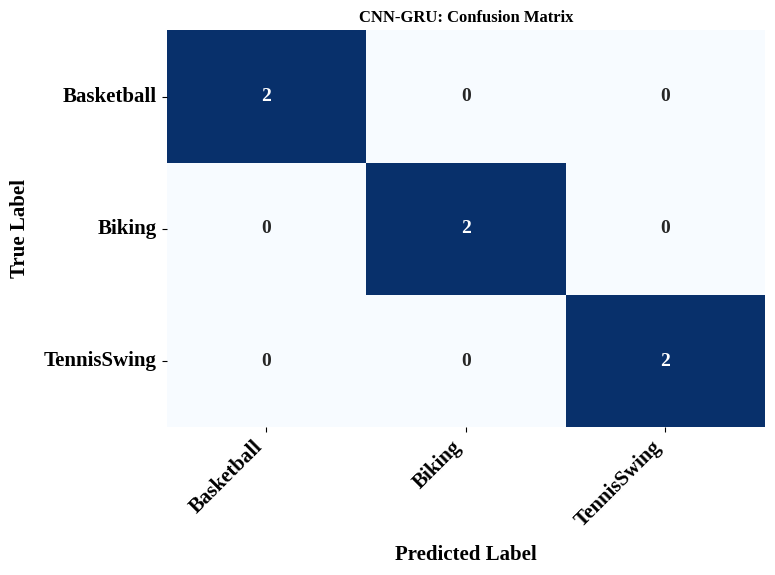

In [ ]:
plot_confusion_matrix(
    model=video_recurrent_model,
    X_test=X_test,
    y_test=y_test,
    class_names=SELECTED_CLASSES,
    model_name="CNN-GRU"
)

In [ ]:
import pandas as pd

total_tokens = 0
correct_tokens = 0
total_sequences = len(encoder_input_test)
correct_sequences = 0

sample_records = []

print("Evaluating Autoregressive Test Predictions...")
for i in range(total_sequences):
    inp = encoder_input_test[i:i+1]
    true_rev = y_raw[split + i].tolist()

    pred_rev = decode_sequence(inp)

    # Token-level matching
    min_len = min(len(true_rev), len(pred_rev))
    matched = sum(1 for t, p in zip(true_rev[:min_len], pred_rev[:min_len]) if t == p)

    correct_tokens += matched
    total_tokens += len(true_rev)

    # Sequence-level matching
    if true_rev == pred_rev:
        correct_sequences += 1

    # Collect first 5 test samples for the laboratory report
    if i < 5:
        sample_records.append({
            "Sample": i + 1,
            "Input Sequence": str(inp[0].tolist()),
            "True Target": str(true_rev),
            "Predicted Output": str(pred_rev)
        })

# Compute final accuracies
token_accuracy = (correct_tokens / total_tokens) * 100
sequence_accuracy = (correct_sequences / total_sequences) * 100
final_tr_loss = history_seq2seq.history['loss'][-1]
final_val_loss = history_seq2seq.history['val_loss'][-1]

# Display Report Metrics Table
metrics_df = pd.DataFrame([{
    "Training Loss": f"{final_tr_loss:.4f}",
    "Validation Loss": f"{final_val_loss:.4f}",
    "Token Accuracy": f"{token_accuracy:.2f}%",
    "Sequence Accuracy": f"{sequence_accuracy:.2f}%"
}])



NameError: name 'encoder_input_test' is not defined

In [ ]:
print("Sequence to sequence evaluation:")
print(metrics_df.to_string(index=False))

# Display Required Sample Output Table
samples_df = pd.DataFrame(sample_records)[["Sample", "Input Sequence", "Predicted Output"]]
print("Test inputs and outputs")

In [ ]:
print("hi")

hi


In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding
from tensorflow.keras.models import Model
import re # Import the regular expression module

# 1. SYNTHETIC DATASET GENERATION
NUM_SAMPLES = 5000       # Dataset size
SEQ_LEN = 6              # Sequence length
VOCAB_SIZE = 20          # Integers from 1 to 20
EMBED_DIM = 32
LATENT_DIM = 64

PAD_TOKEN = 0
SOS_TOKEN = VOCAB_SIZE + 1  # 21
EOS_TOKEN = VOCAB_SIZE + 2  # 22
TOTAL_VOCAB = VOCAB_SIZE + 3

np.random.seed(42)
X_raw = np.random.randint(1, VOCAB_SIZE + 1, size=(NUM_SAMPLES, SEQ_LEN))
y_raw = np.flip(X_raw, axis=1)

# Teacher forcing inputs/targets
decoder_input_data = np.hstack([np.full((NUM_SAMPLES, 1), SOS_TOKEN), y_raw])
decoder_target_data = np.hstack([y_raw, np.full((NUM_SAMPLES, 1), EOS_TOKEN)])

# Split data
split = int(0.8 * NUM_SAMPLES)
encoder_input_train = X_raw[:split]
decoder_input_train = decoder_input_data[:split]
decoder_target_train = decoder_target_data[:split]

encoder_input_test = X_raw[split:]
decoder_input_test = decoder_input_data[split:]
decoder_target_test = decoder_target_data[split:]

# 2. MODEL ARCHITECTURE & TRAINING
# Encoder
encoder_inputs = Input(shape=(None,), name="encoder_inputs")
enc_emb = Embedding(input_dim=TOTAL_VOCAB, output_dim=EMBED_DIM, mask_zero=True)(encoder_inputs)
encoder_lstm = LSTM(LATENT_DIM, return_state=True, name="encoder_lstm")
_, state_h, state_c = encoder_lstm(enc_emb)
encoder_states = [state_h, state_c]

# Decoder
decoder_inputs = Input(shape=(None,), name="decoder_inputs")
dec_emb_layer = Embedding(input_dim=TOTAL_VOCAB, output_dim=EMBED_DIM, mask_zero=True)
dec_emb = dec_emb_layer(decoder_inputs)

decoder_lstm = LSTM(LATENT_DIM, return_sequences=True, return_state=True, name="decoder_lstm")
decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)

decoder_dense = Dense(TOTAL_VOCAB, activation="softmax", name="decoder_dense")
decoder_outputs = decoder_dense(decoder_outputs)

# Train model
seq2seq_model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Training Seq2Seq Reversal Model (batch_size=2, epochs=30)...")
history_seq2seq = seq2seq_model.fit(
    [encoder_input_train, decoder_input_train],
    np.expand_dims(decoder_target_train, -1),
    validation_data=(
        [encoder_input_test, decoder_input_test],
        np.expand_dims(decoder_target_test, -1)
    ),
    batch_size=2,
    epochs=30,
    verbose=1
)

#  AUTOREGRESSIVE INFERENCE SETUP
encoder_model_inf = Model(encoder_inputs, encoder_states)

decoder_state_input_h = Input(shape=(LATENT_DIM,))
decoder_state_input_c = Input(shape=(LATENT_DIM,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

dec_emb_inf = dec_emb_layer(decoder_inputs)
decoder_outputs_inf, state_h_inf, state_c_inf = decoder_lstm(
    dec_emb_inf, initial_state=decoder_states_inputs
)
decoder_states_inf = [state_h_inf, state_c_inf]
decoder_outputs_inf = decoder_dense(decoder_outputs_inf)

decoder_model_inf = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs_inf] + decoder_states_inf
)

def decode_sequence(input_seq):
    states_value = encoder_model_inf.predict(input_seq, verbose=0)
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = SOS_TOKEN
    decoded_tokens = []

    for _ in range(SEQ_LEN):
        output_tokens, h, c = decoder_model_inf.predict(
            [target_seq] + states_value, verbose=0
        )
        sampled_token_index = np.argmax(output_tokens[0, -1, :])
        if sampled_token_index == EOS_TOKEN:
            break
        decoded_tokens.append(sampled_token_index)
        target_seq[0, 0] = sampled_token_index
        states_value = [h, c]

    return decoded_tokens

# EVALUATION & REQUIRED TABLE OUTPUTS
total_tokens = 0
correct_tokens = 0
total_sequences = len(encoder_input_test)
correct_sequences = 0
sample_records = []

print("\nEvaluating Autoregressive Test Predictions...")
for i in range(total_sequences):
    inp = encoder_input_test[i:i+1]
    true_rev = y_raw[split + i].tolist()
    pred_rev = decode_sequence(inp)

    # Token accuracy
    min_len = min(len(true_rev), len(pred_rev))
    matched = sum(1 for t, p in zip(true_rev[:min_len], pred_rev[:min_len]) if t == p)
    correct_tokens += matched
    total_tokens += len(true_rev)

    # Sequence accuracy
    if true_rev == pred_rev:
        correct_sequences += 1

    # Store first 5 test samples for report
    if i < 5:
        sample_records.append({
            "Sample": i + 1,
            "Input Sequence": str(inp[0].tolist()),
            "True Target": str(true_rev),
            "Predicted Output": str(pred_rev)
        })

token_accuracy = (correct_tokens / total_tokens) * 100
sequence_accuracy = (correct_sequences / total_sequences) * 100
final_tr_loss = history_seq2seq.history['loss'][-1]
final_val_loss = history_seq2seq.history['val_loss'][-1]

# Display Summary Tables
metrics_df = pd.DataFrame([{
    "Training Loss": f"{final_tr_loss:.4f}",
    "Validation Loss": f"{final_val_loss:.4f}",
    "Token Accuracy": f"{token_accuracy:.2f}%",
    "Sequence Accuracy": f"{sequence_accuracy:.2f}%"
}])

samples_df = pd.DataFrame(sample_records)[["Sample", "Input Sequence", "Predicted Output"]]

# Clean up the string representation of lists as previously requested
samples_df['Input Sequence'] = samples_df['Input Sequence'].apply(lambda x: '[' + ', '.join(re.findall(r'\d+', x)) + ']')
samples_df['Predicted Output'] = samples_df['Predicted Output'].apply(lambda x: '[' + ', '.join(re.findall(r'\d+', x)) + ']')

print("       SEQUENCE-TO-SEQUENCE EVALUATION METRICS       ")
print(metrics_df.to_string(index=False))

print("          TEST EXAMPLES (INPUT vs PREDICTED)         ")
print("=" * 55)
print(samples_df.to_string(index=False))

Training Seq2Seq Reversal Model (batch_size=2, epochs=30)...
Epoch 1/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.3811 - loss: 1.9871 - val_accuracy: 0.6747 - val_loss: 1.0922
Epoch 2/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8396 - loss: 0.6007 - val_accuracy: 0.9259 - val_loss: 0.3240
Epoch 3/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9565 - loss: 0.2120 - val_accuracy: 0.9617 - val_loss: 0.1792
Epoch 4/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9784 - loss: 0.1129 - val_accuracy: 0.9936 - val_loss: 0.0641
Epoch 5/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9851 - loss: 0.0757 - val_accuracy: 0.9849 - val_loss: 0.0683
Epoch 6/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9871 - loss: 0.0605 - val_accuracy: 0.9937 - val_loss: 0.0404
Epoch 7/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9896 - loss: 0.0469 - val_accuracy: 0.9729 - val_loss: 0.0983
Epoch 8/30
2000/2000 ━